In [ ]:
import torch

# import torch.nn.functional as F
import numpy as np

# import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus

# from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from network.N_BPMSNet import N_BPMSNet

In [ ]:
model = N_BPMSNet()
device = torch.device("cpu")
model_path = "./output/N_BPMSNet_best_iou.pth"
model.load_state_dict(torch.load(model_path, map_location=torch.device("cpu")))
model.eval()

In [ ]:
index, next_index = 4772, 4773  # 4013,4014 #6535,6537

context_1 = np.load("../../dataset/s2/{}.npy".format(index))  # 1192, 1032
context_2 = np.load("../../dataset/s2/{}.npy".format(next_index))  # 1193, 1033
target = (
    np.array(Image.open("../../dataset/mask_gray/" + str(index) + ".jpg").convert("L"))
    / 255
)

ndmi_C1 = (context_1[11, ...] - context_1[12, ...]) / (
    context_1[11, ...] + context_1[12, ...]
)
ndmi_C2 = (context_2[11, ...] - context_2[12, ...]) / (
    context_2[11, ...] + context_2[12, ...]
)
ndmi_C3 = ndmi_C1 - ndmi_C2
ndmi_C1 = np.expand_dims(ndmi_C1, axis=0)
ndmi_C2 = np.expand_dims(ndmi_C2, axis=0)
ndmi_C3 = np.expand_dims(ndmi_C3, axis=0)
context_3 = np.concatenate([ndmi_C1, ndmi_C2, ndmi_C3], axis=0)

mid_loc_x = context_1.shape[1] // 2
mid_loc_y = context_1.shape[2] // 2
s = 80
context_1 = context_1[:, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]
context_2 = context_2[:, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]
context_3 = context_3[:, mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]
target = target[mid_loc_x - s : mid_loc_x + s, mid_loc_y - s : mid_loc_y + s]

context_1 = torch.Tensor(context_1).unsqueeze(0).to(device)
context_2 = torch.Tensor(context_2).unsqueeze(0).to(device)
context_3 = torch.Tensor(context_3).unsqueeze(0).to(device)

output = model(context_1, context_2, context_3)

torch.Size([1, 160, 160])
torch.Size([1, 160, 160])


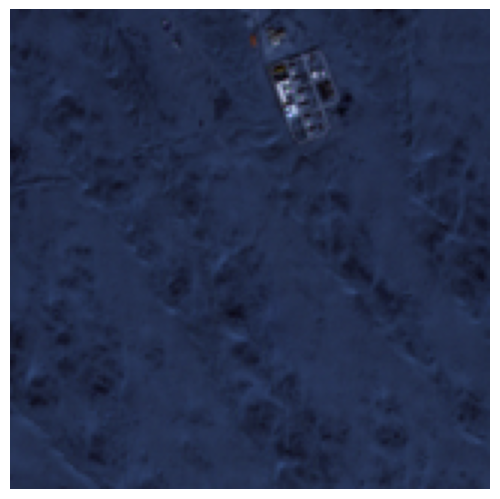

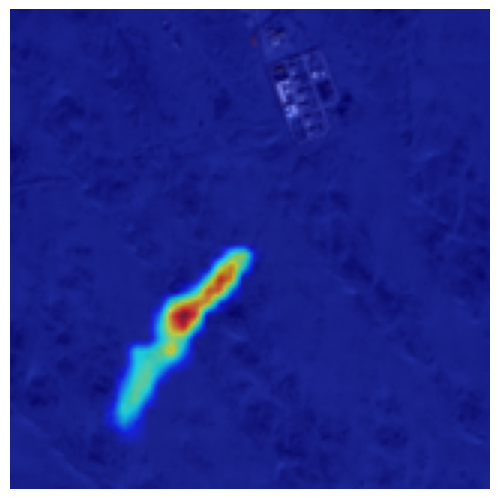

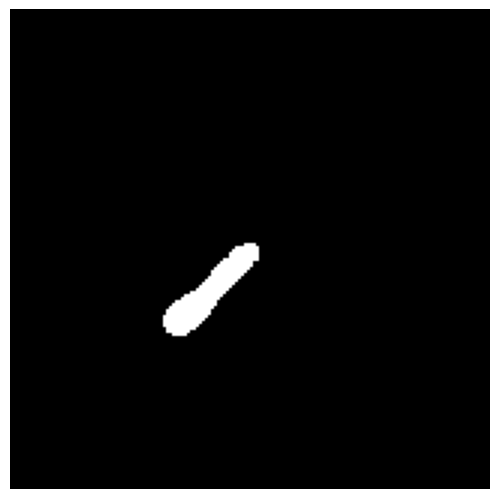

In [ ]:
import torch.nn as nn


class SegmentationTarget:
    def __init__(self, channel=0):
        self.channel = channel

    def __call__(self, model_output):
        print(model_output.shape)
        return model_output[self.channel, :, :].mean()


class ModelWrapper(nn.Module):
    def __init__(self, model, context_1, context_2, context_3):
        super().__init__()
        self.model = model
        self.context_1 = context_1
        self.context_2 = context_2
        self.context_3 = context_3

    def forward(self, x):
        output_tuple = self.model(self.context_1, self.context_2, self.context_3)
        if isinstance(output_tuple, tuple):
            return output_tuple[-1]
        return output_tuple


wrapped_model = ModelWrapper(model, context_1, context_2, context_3)
target_layers = [model.decoder_final[-1]]
targets = [SegmentationTarget(channel=0)]
cam = GradCAM(model=wrapped_model, target_layers=target_layers)
cam_pp = GradCAMPlusPlus(model=wrapped_model, target_layers=target_layers)

dummy_input = torch.randn(1, 3, 160, 160)
grayscale_cam = cam(input_tensor=dummy_input, targets=targets)[0, :]
grayscale_cam_pp = cam_pp(input_tensor=dummy_input, targets=targets)[0, :]


rgb_img = context_1[0, 1:4].permute(1, 2, 0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

vis_cam = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
vis_cam_pp = show_cam_on_image(rgb_img, grayscale_cam_pp, use_rgb=True)


plt.imshow(rgb_img)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# plt.title("Grad-CAM")
plt.imshow(vis_cam)
# plt.colorbar()
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# plt.title("Target")
plt.imshow(target, cmap="gray")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [81]:
grayscale_cam_pp.shape

(160, 160)